In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

import run_fair

from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import seaborn as sns
from cmcrameri import cm

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

In [3]:
# Run fair for train/test
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)
dt = 1
freq_s = 1
nperseg = 250
fair_train = run_fair.initialise_fair(start, stop)
fair_test = run_fair.initialise_fair(start, stop)

#co2_train = np.linspace(0, 10, n_steps)
co2_train = np.random.randn(n_steps)
co2_test = np.linspace(0, 5, n_steps)
nan_force = np.linspace(0, 0, n_steps)

agents = ['CO2','CH4','N2O','Sulfur','BC']
emission_dict_train = {
  'CO2':co2_train,
  'CH4':nan_force,
  'N2O':nan_force,
  'Sulfur':nan_force,
  'BC':nan_force
}

emission_dict_test = {
  'CO2':co2_test,
  'CH4':nan_force,
  'N2O':nan_force,
  'Sulfur':nan_force,
  'BC':nan_force
}

t, T_ens, T_train, ECS = run_fair.run_multi_agent(fair_train, n_steps, years, agents, emission_dict_train)
t, T_ens, T_test, ECS = run_fair.run_multi_agent(fair_test, n_steps, years, agents, emission_dict_test)

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

In [2]:
all_scenarios = ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp534-over', 'ssp585','pulse','step','noise']
fair_scenarios = ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp534-over', 'ssp585']
ghgs = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict = {}

start, stop = 1750, 2100
years = np.arange(start, stop)
n_steps = len(years)

for scen in all_scenarios:
  emis_dict[scen] = {}
  for ghg in ghgs:
    if scen in fair_scenarios:
      emis_dict[scen][ghg] = run_fair.get_scenario_agent(scen, ghg)
    elif scen == 'pulse':
      pulse = np.zeros(n_steps)
      pulse[0] = 1000
      emis_dict[scen][ghg] = pulse
    elif scen == 'step':
      step = np.zeros(n_steps)
      year_step = 50
      step[year_step:] = 10
      emis_dict[scen][ghg] = step
    elif scen == 'noise':
      noise = np.random.randn(n_steps)
      emis_dict[scen][ghg] = noise * 100

In [4]:

nan_force = np.zeros(n_steps)
delT_1ghg_dict = {}

ghgs_lim = ['CO2']

for scen in all_scenarios:
  delT_1ghg_dict[scen] = {}

  for ghg in ghgs_lim:
    fair_train = run_fair.initialise_fair(start, stop)
    emis_dict_train = {
      'CO2':emis_dict[scen][ghg] if ghg == 'CO2' else nan_force,
      'CH4':emis_dict[scen][ghg] if ghg == 'CH4' else nan_force,
      'N2O':emis_dict[scen][ghg] if ghg == 'N2O' else nan_force,
      'Sulfur':emis_dict[scen][ghg] if ghg == 'Sulfur' else nan_force,
      'BC':emis_dict[scen][ghg] if ghg == 'BC' else nan_force,
    }
    t, T_ens, T_train, ECS = run_fair.run_multi_agent(fair_train, n_steps, years, ghgs, emis_dict_train)
    delT_1ghg_dict[scen][ghg] = T_train

Running 66 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

...

Running 66 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/351 [00:00<?, ?timesteps/s]

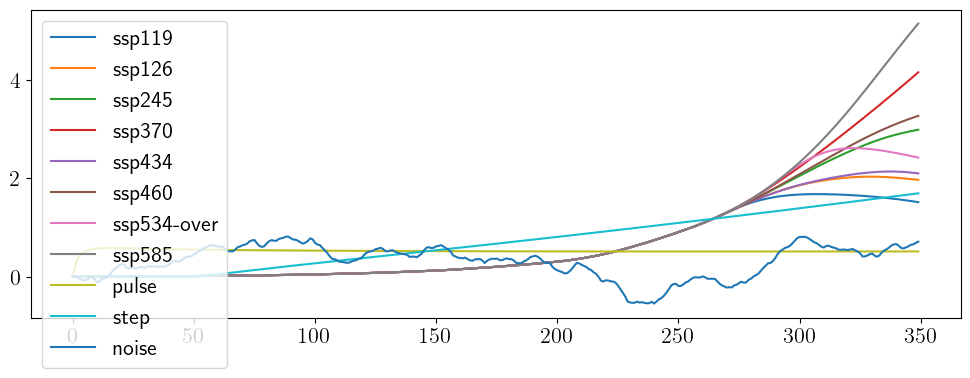

In [5]:
for scen in all_scenarios:
  for ghg in ghgs_lim:
    plt.plot(delT_1ghg_dict[scen][ghg], label=scen)

plt.legend(loc='upper left')

In [49]:
def _ema(e, tau):
  # exponential moving average
  a = 1.0 - np.exp(-1.0 / float(tau))
  s = 0.0
  out = np.empty_like(e)
  for i, v in enumerate(e):
    s += a * (v - s)
    out[i] = s
  return out

def make_features(emissions, extras=None, n_lags=10, n_extra=None):
  e = np.asarray(emissions, float).ravel(); N = e.size
  X = np.zeros((N, n_lags + 1))
  for k in range(n_lags + 1):
    X[k:, k] = e[:N - k]  # zeros for out-of-bounds
  cumu = np.cumsum(e)                                # cumulative emissions
  ema2, ema15, ema100 = _ema(e, 2.0), _ema(e, 15.0), _ema(e, 100.0)  # EMAs
  base = np.column_stack([X, cumu, ema2, ema15, ema100])

  ex = [] if extras is None else [np.asarray(f, float).ravel() for f in extras]
  n_extra = len(ex) if n_extra is None else n_extra
  cols = []
  for f in ex:                                      # truncate/pad extras to N
    v = np.zeros(N); v[:min(N, f.size)] = f[:N]; cols.append(v)
  for _ in range(n_extra - len(cols)):
    cols.append(np.zeros(N))  # pad to consistent width
  return np.column_stack([base] + cols) if cols else base

def train_mlp(emissions, gmst, extras=None, n_lags=10, random_state=0):
  X = make_features(emissions, extras, n_lags)
  y = np.asarray(gmst, float)[:X.shape[0]]
  model = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(64, 64), activation="relu",
                 max_iter=5000, early_stopping=True, random_state=random_state, shuffle=False)
  )
  model.fit(X, y)
  return model

def train_mlp_multi(series_list, n_lags=10, random_state=0):
  # series_list: [(emissions1, gmst1, extras1_or_None), (emissions2, gmst2, extras2_or_None), ...]
  Xs, ys = [], []
  for e, y, ex in series_list:
      Xi = make_features(e, ex, n_lags)
      yi = np.asarray(y, float)[:Xi.shape[0]]
      Xs.append(Xi)
      ys.append(yi)

  X = np.vstack(Xs)
  Y = np.concatenate(ys)  # stack unrelated series row-wise

  model = make_pipeline(
      StandardScaler(),
      MLPRegressor(hidden_layer_sizes=(4, 4), activation="relu",
                    max_iter=5000, early_stopping=True, random_state=random_state, shuffle=False)
  )
  model.fit(X, Y)
  return model

def _new_model(random_state=0):
  return make_pipeline(
      StandardScaler(),
      MLPRegressor(hidden_layer_sizes=(8, 8), activation="relu",
                    max_iter=5000, early_stopping=True, random_state=random_state, shuffle=False)
  )

def evaluate_trainsets_vs_tests(train_scenarios, train_series, test_scenarios, test_series, n_lags=10, random_state=0):
  # series: [(emissions, gmst, extras_or_None), (...), ...]
  all_series = list(train_series) + list(test_series)
  n_extra_max = max((len(s[2]) if s[2] is not None else 0) for s in all_series)  # unify feature dim
  def features(s):  # build X,y for a series
    e, y, ex = s
    X = make_features(e, ex, n_lags=n_lags, n_extra=n_extra_max)
    y = np.asarray(y, float)[:X.shape[0]]
    return X, y

  error_dict, yhat_dict = {}, {}
  for i, train in enumerate(train_scenarios):
    Xtr, ytr = features(train_series[i])
    model = _new_model(random_state=random_state)
    model.fit(Xtr, ytr)
    error_dict[train], yhat_dict[train] = {}, {}
    for j, test in enumerate(test_scenarios):
      Xte, yte = features(test_series[j])
      yhat = model.predict(Xte)
      error_dict[train][test] = nrmse(yte, yhat)  # normalized by max of y_test
      yhat_dict[train][test] = yhat

  return error_dict, yhat_dict

def plot_yhats_grid(error_dict, yhat_dict, ytrue_dict):
  train_scenarios = sorted(error_dict.keys())
  test_scenarios = sorted({test for train in train_scenarios for test in error_dict[train].keys()})
  n_test = len(test_scenarios)
  cols = int(np.ceil(np.sqrt(n_test))); rows = int(np.ceil(n_test / cols))
  fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), constrained_layout=True, sharex=True)

  for i, test in enumerate(test_scenarios):
    ax = axes[i // cols][i % cols]
    for j, train in enumerate(train_scenarios):
      if train in yhat_dict.get(test, {}):
        ax.plot(yhat_dict[train][test], lw=1, alpha=0.8, label=train)  # all yhats for this test
    ax.plot(ytrue_dict[test]['CO2'], lw=2, alpha=0.8, label='True', c='k')
    ax.legend(loc='upper left', fontsize=8)

    ax.set_title(f"Test {test}")
    ax.set_xlabel("t")
    ax.set_ylabel("yhat")
    ax.set_ylim([-0.5,6])

  for k in range(n_test, rows*cols):
    axes[k // cols][k % cols].axis('off')  # hide empties

  return

def predict_series(model, emissions, extras=None, n_lags=10):
  return model.predict(make_features(emissions, extras, n_lags))

def rmse(y_true, y_pred):
  y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
  return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def nrmse(y_true, y_pred):
  denom = max(np.max(np.abs(y_true)), 1e-12)  # normalize by largest magnitude in y_test
  return rmse(y_true/denom, y_pred/denom)

In [50]:
train_series = []
for scen in all_scenarios:
  for ghg in ghgs_lim:
    train_series.append((emis_dict[scen][ghg], delT_1ghg_dict[scen][ghg], None))

error_dict, yhat_dict = evaluate_trainsets_vs_tests(all_scenarios, train_series, all_scenarios, train_series, n_lags=10, random_state=0)

/Users/chriswomack/anaconda3/envs/research/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


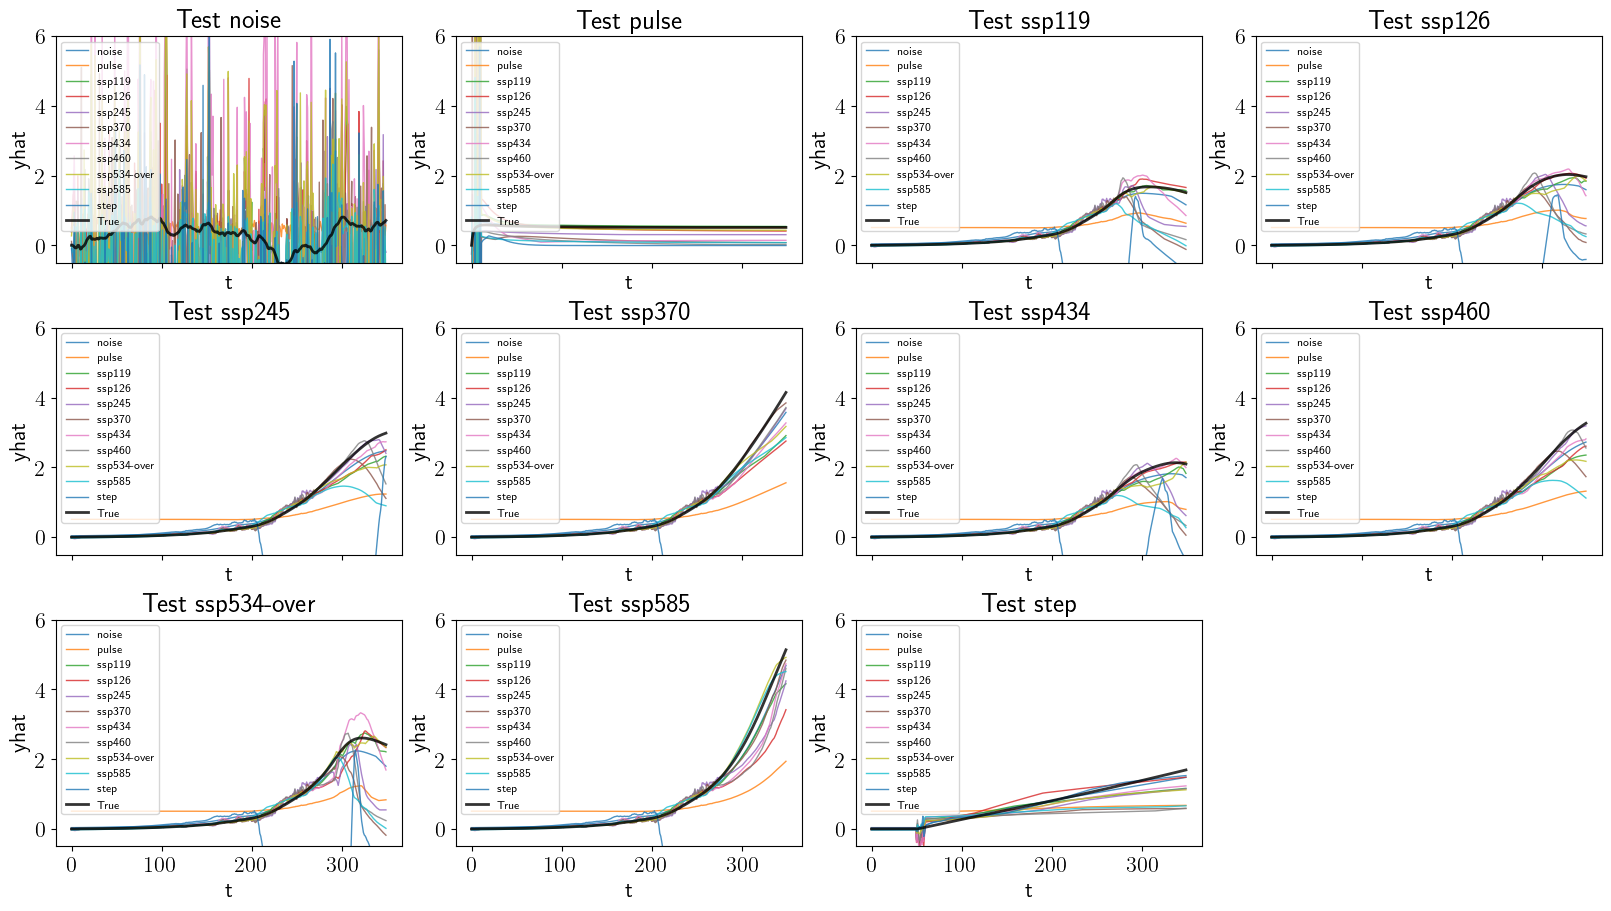

In [51]:
plot_yhats_grid(error_dict, yhat_dict, delT_1ghg_dict)

Text(0.5, 0.98, 'Small Neural Network Trained to Emulate FaIR')

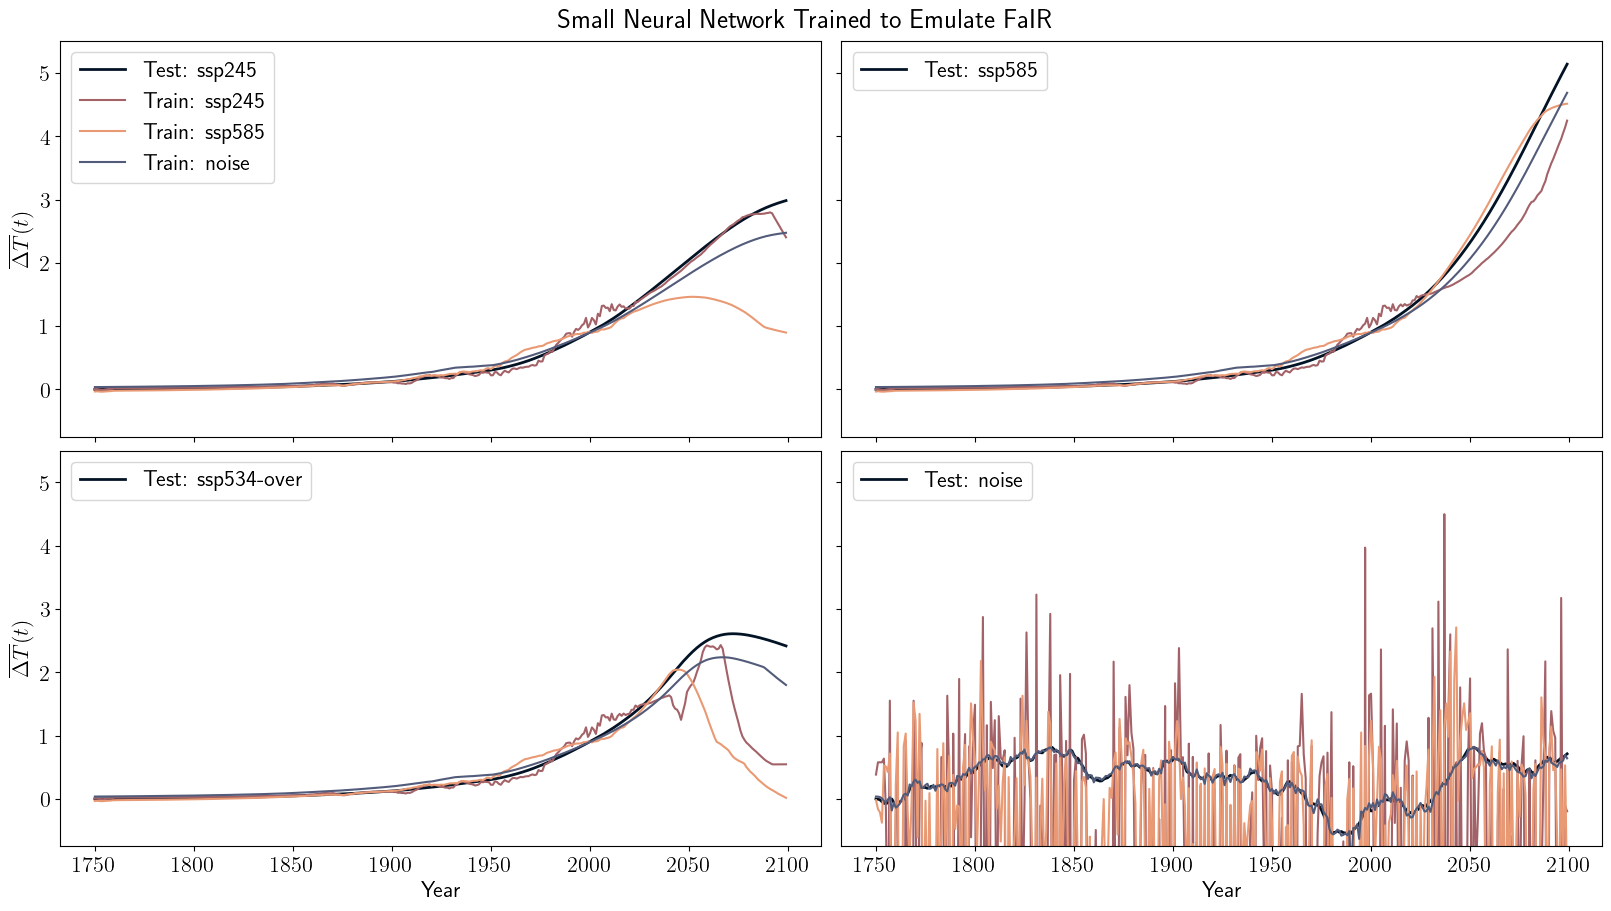

In [120]:
years = np.arange(1750, 2100)

fig, ax = plt.subplots(2, 2, figsize=(16, 9), constrained_layout=True, sharex=True, sharey=True)
ax[0,0].plot(years, delT_1ghg_dict['ssp245']['CO2'], c=cm.lipariS(0), lw=2, label='Test: ssp245')
ax[0,0].plot(years, yhat_dict['ssp245']['ssp245'], c=cm.lipariS(2), lw=1.5, label='Train: ssp245')
ax[0,0].plot(years, yhat_dict['ssp585']['ssp245'], c=cm.lipariS(3), lw=1.5, label='Train: ssp585')
ax[0,0].plot(years, yhat_dict['noise']['ssp245'], c=cm.lipariS(4), lw=1.5, label='Train: noise')
ax[0,0].legend(loc='upper left')
ax[0,0].set_ylabel(r'$\overline{\Delta T}(t)$')

ax[0,1].plot(years, delT_1ghg_dict['ssp585']['CO2'], c=cm.lipariS(0), lw=2, label='Test: ssp585')
ax[0,1].plot(years, yhat_dict['ssp245']['ssp585'], c=cm.lipariS(2), lw=1.5)
ax[0,1].plot(years, yhat_dict['ssp585']['ssp585'], c=cm.lipariS(3), lw=1.5)
ax[0,1].plot(years, yhat_dict['noise']['ssp585'], c=cm.lipariS(4), lw=1.5)
ax[0,1].legend()

ax[1,0].plot(years, delT_1ghg_dict['ssp534-over']['CO2'], c=cm.lipariS(0), lw=2, label='Test: ssp534-over')
ax[1,0].plot(years, yhat_dict['ssp245']['ssp534-over'], c=cm.lipariS(2), lw=1.5)
ax[1,0].plot(years, yhat_dict['ssp585']['ssp534-over'], c=cm.lipariS(3), lw=1.5)
ax[1,0].plot(years, yhat_dict['noise']['ssp534-over'], c=cm.lipariS(4), lw=1.5)
ax[1,0].legend(loc='upper left')
ax[1,0].set_ylabel(r'$\overline{\Delta T}(t)$')
ax[1,0].set_xlabel('Year')

ax[1,1].plot(years, delT_1ghg_dict['noise']['CO2'], c=cm.lipariS(0), lw=2, label='Test: noise')
ax[1,1].plot(years, yhat_dict['ssp245']['noise'], c=cm.lipariS(2), lw=1.5)
ax[1,1].plot(years, yhat_dict['ssp585']['noise'], c=cm.lipariS(3), lw=1.5)
ax[1,1].plot(years, yhat_dict['noise']['noise'], c=cm.lipariS(4), lw=1.5)
ax[1,1].legend(loc='upper left')
ax[1,1].set_ylim([-0.75, 5.5])
ax[1,1].set_xlabel('Year')

fig.suptitle('Small Neural Network Trained to Emulate FaIR')

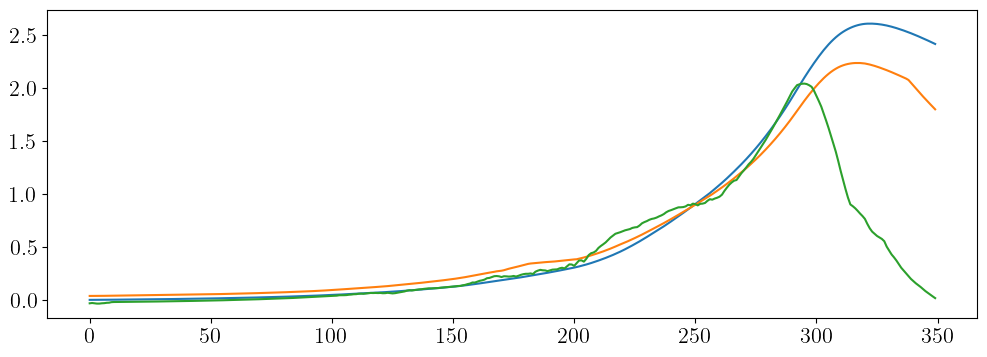

In [68]:
plt.plot()
plt.plot(yhat_dict['noise']['ssp534-over'])
plt.plot()

In [34]:
def plot_error_heatmap(error_dict, train_scenarios, test_scenarios, ax=None):
  # Build matrix with rows=test, cols=train
  E = np.full((len(test_scenarios), len(train_scenarios)), np.nan)
  for r, te in enumerate(test_scenarios):
    for c, tr in enumerate(train_scenarios):
      E[r, c] = error_dict.get(tr, {}).get(te, np.nan)

  # Add labels that are the actual numbers
  labels = np.empty_like(E, dtype=object)
  for i in range(E.shape[0]):
    for j in range(E.shape[1]):
      v = E[i, j]
      labels[i, j] = "" if not np.isfinite(v) else f"{v:.3g}"

  # Plot
  if ax is None:
    fig, ax = plt.subplots(figsize=(1.2*len(train_scenarios)+2, 1.0*len(test_scenarios)+2), constrained_layout=True)
  else:
    fig = ax.figure
  sns.heatmap(E, ax=ax, vmin=0, vmax=1, cmap=cm.lajolla_r,
              xticklabels=train_scenarios, yticklabels=test_scenarios,
              annot=True, fmt=".2g", cbar_kws={"label": "NRMSE / global max"})
  ax.set_xlabel("Train scenario")
  ax.set_ylabel("Test scenario")
  ax.set_title("Error heatmap")
  return

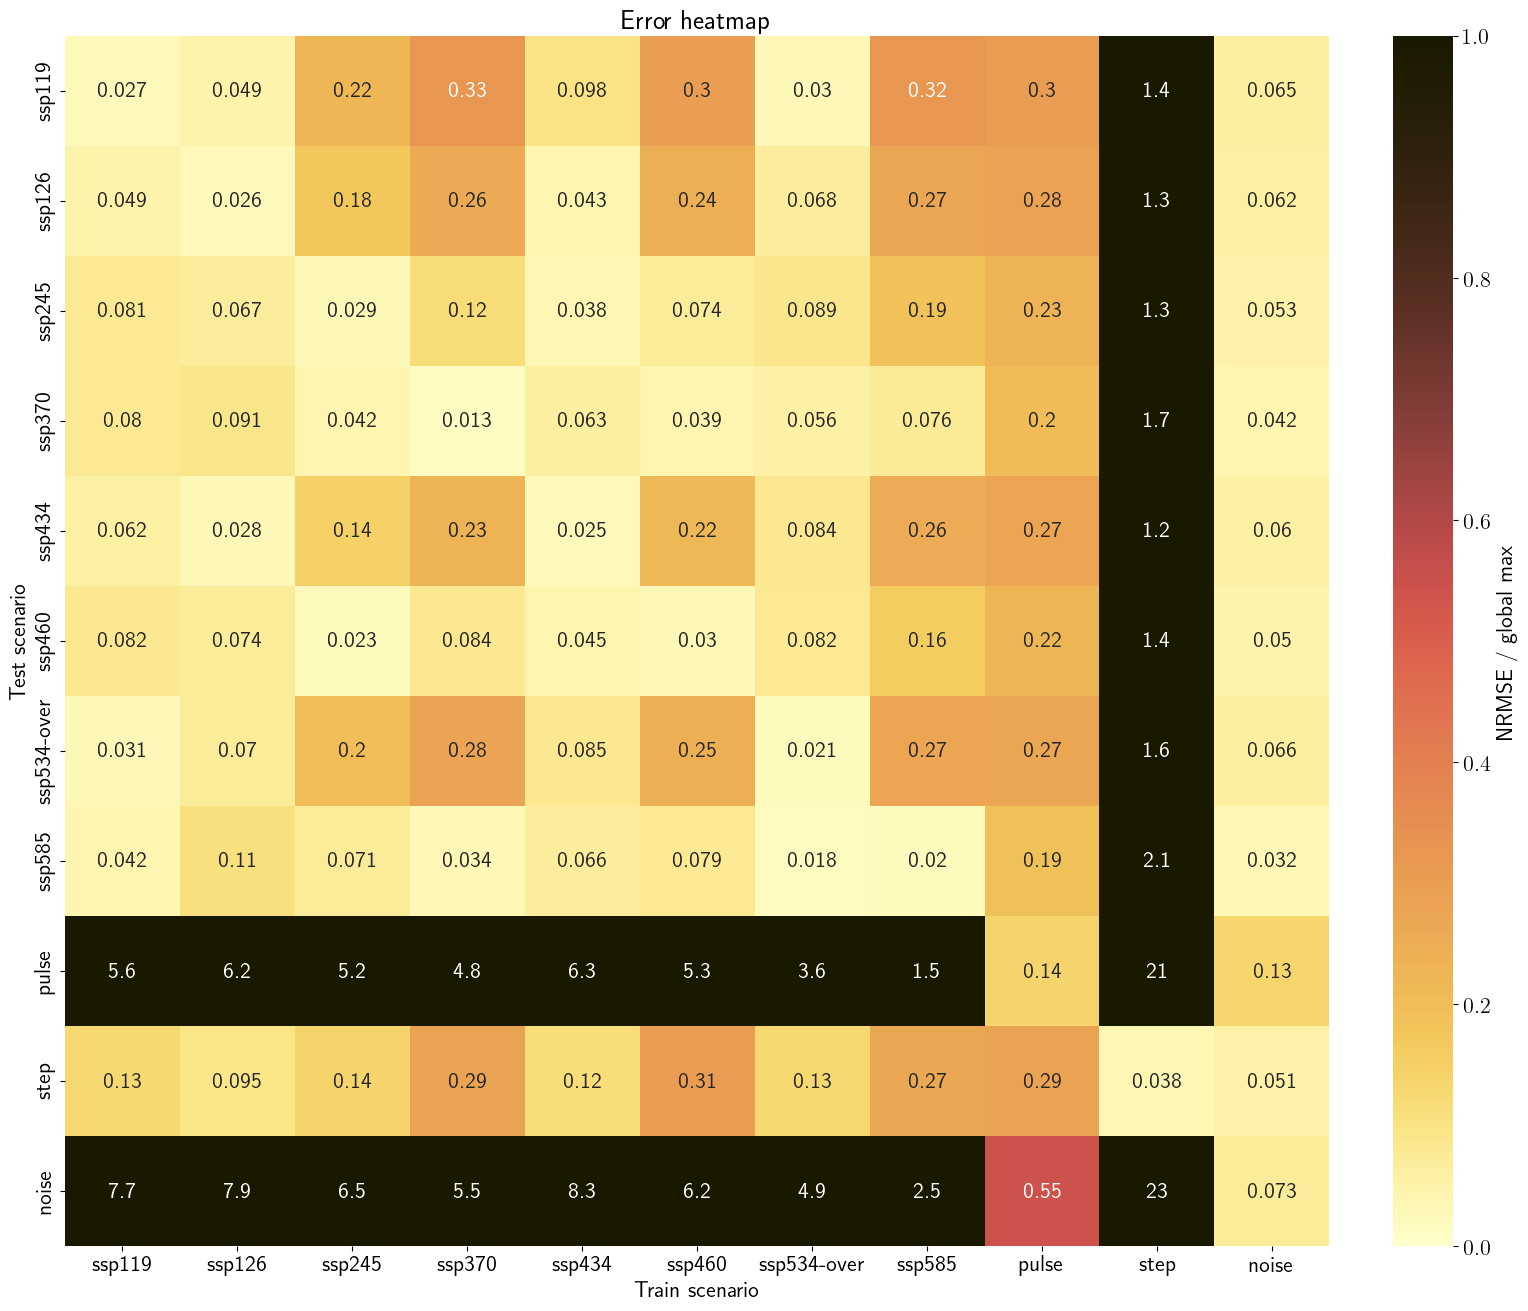

In [53]:
plot_error_heatmap(error_dict, all_scenarios, all_scenarios)